In [1]:
# 检查 GPU
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# 安装依赖（Colab 通常已有 torch，如需指定版本可取消注释下一行）
# !pip install torch torchvision --quiet
!pip install tqdm --quiet

In [3]:
# ---------- 方式 A：用 kagglehub 下载（推荐）---------
# 数据集必须为 mostafaabla/garbage-classification（不要用 asdasdasasdas）
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
print("Downloaded to:", path)

# 自动查找包含类别子文件夹的根目录（kagglehub 可能多一层目录）
from pathlib import Path
def _norm(s): return s.lower().replace(' ', '_').replace('-', '_')
KNOWN_CLASSES = {'paper', 'cardboard', 'metal', 'plastic', 'biological', 'trash', 'batteries', 'green_glass', 'brown_glass', 'white_glass', 'clothes', 'clothing', 'shoes'}
def find_data_root(p, depth=3):
    p = Path(p)
    if not p.exists(): return None
    for _ in range(depth + 1):
        subdirs = {_norm(x.name) for x in p.iterdir() if x.is_dir()}
        if KNOWN_CLASSES & subdirs: return str(p)
        for d in p.iterdir():
            if d.is_dir():
                found = find_data_root(d, depth - 1)
                if found: return found
    return None
DATA_DIR = find_data_root(path) or str(path)
print("DATA_DIR:", DATA_DIR)

# ---------- 方式 B：Kaggle CLI 或 Google Drive ----------
# DATA_DIR = 'garbage-classification'  # 解压后目录

Using Colab cache for faster access to the 'garbage-classification' dataset.
Downloaded to: /kaggle/input/garbage-classification
DATA_DIR: /kaggle/input/garbage-classification/garbage_classification


## 3. Data Processing

In [4]:
import os
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

TARGET_NAMES = ['Recyclables', 'Organics', 'Garbage']
IMG_SIZE = 224

FOLDER_TO_3CLASS = {
    'paper': 0, 'cardboard': 0, 'metal': 0, 'plastic': 0,
    'green_glass': 0, 'green glass': 0, 'green-glass': 0,
    'brown_glass': 0, 'brown glass': 0, 'brown-glass': 0,
    'white_glass': 0, 'white glass': 0, 'white-glass': 0,
    'clothing': 0, 'clothes': 0, 'shoes': 0,
    'biological': 1, 'biological_waste': 1, 'biological waste': 1,
    'trash': 2, 'general_trash': 2, 'general trash': 2,
    'batteries': 2,
}

def get_class_mapping():
    m = {}
    for k, v in FOLDER_TO_3CLASS.items():
        m[k.lower().replace(' ', '_')] = v
        m[k] = v
    return m

class WasteClassificationDataset(Dataset):
    def __init__(self, root_dir, transform=None, use_3_class=True, indices=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.use_3_class = use_3_class
        self.samples = []
        self.class_mapping = get_class_mapping()
        self.indices = indices
        self._load_samples()

    def _normalize(self, name):
        return name.lower().replace(' ', '_').replace('-', '_')

    def _get_target(self, folder_name):
        norm = self._normalize(folder_name)
        out = self.class_mapping.get(norm, -1)
        if out >= 0:
            return out
        for k, v in FOLDER_TO_3CLASS.items():
            if k in norm or norm in k:
                return v
        return -1

    def _load_samples(self):
        def scan(path):
            for item in path.iterdir():
                if item.is_dir():
                    target = self._get_target(item.name)
                    if self.use_3_class and target < 0:
                        continue
                    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                        for img_path in item.glob(ext):
                            self.samples.append((str(img_path), target))
        if not self.root_dir.exists():
            raise FileNotFoundError(f'Dataset not found: {self.root_dir}')
        scan(self.root_dir)
        if len(self.samples) == 0:
            for sub in ['archive', 'garbage-classification', 'data', 'train', 'valid', 'test']:
                p = self.root_dir / sub
                if p.exists():
                    scan(p)
                    if self.samples:
                        break
        if len(self.samples) == 0:
            raise ValueError(f'No images in {self.root_dir}')

    def __len__(self):
        return len(self.indices) if self.indices is not None else len(self.samples)

    def __getitem__(self, idx):
        real_idx = self.indices[idx] if self.indices is not None else idx
        img_path, label = self.samples[real_idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.2),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

def get_dataloaders(data_dir, batch_size=32, val_ratio=0.15, test_ratio=0.15, num_workers=2, seed=42):
    full_ds = WasteClassificationDataset(root_dir=data_dir, transform=None, use_3_class=True)
    n = len(full_ds.samples)
    indices = torch.randperm(n, generator=torch.Generator().manual_seed(seed)).tolist()
    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)
    n_train = n - n_test - n_val
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train+n_val]
    test_idx = indices[n_train+n_val:]
    train_ds = WasteClassificationDataset(data_dir, transform=get_transforms(True), use_3_class=True, indices=train_idx)
    val_ds = WasteClassificationDataset(data_dir, transform=get_transforms(False), use_3_class=True, indices=val_idx)
    test_ds = WasteClassificationDataset(data_dir, transform=get_transforms(False), use_3_class=True, indices=test_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader, 3

In [5]:
# 数据统计
ds = WasteClassificationDataset(DATA_DIR, transform=get_transforms(False), use_3_class=True)
counts = {}
for _, label in ds.samples:
    counts[label] = counts.get(label, 0) + 1
print('Dataset Statistics (3-class):')
for i, name in enumerate(TARGET_NAMES):
    print(f'  {name}: {counts.get(i, 0)}')
print(f'  Total: {len(ds)}')

Dataset Statistics (3-class):
  Recyclables: 12888
  Organics: 985
  Garbage: 697
  Total: 14570


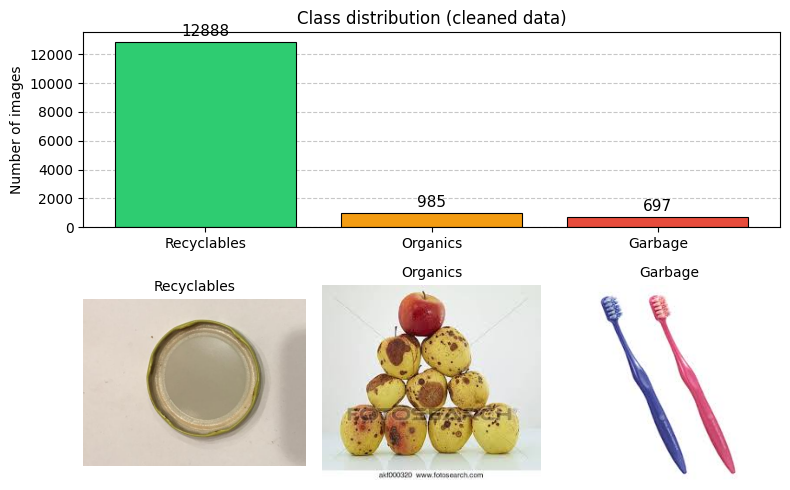

Saved: data_cleaning_fig.png


In [6]:
# Class distribution figure for report (save as data_cleaning_fig.png)
import matplotlib.pyplot as plt
import numpy as np

# Counts per class (use same ds from previous cell)
counts = {}
for _, label in ds.samples:
    counts[label] = counts.get(label, 0) + 1
classes = [TARGET_NAMES[i] for i in range(3)]
values = [counts.get(i, 0) for i in range(3)]

fig = plt.figure(figsize=(8, 5))
# Top: bar chart
ax1 = fig.add_subplot(2, 1, 1)
bars = ax1.bar(classes, values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Number of images')
ax1.set_title('Class distribution (cleaned data)')
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
for bar, v in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, str(v), ha='center', va='bottom', fontsize=11)

# Bottom: one sample image per class
sample_paths = {}
for path, label in ds.samples:
    if label not in sample_paths:
        sample_paths[label] = path
for i in range(3):
    ax = fig.add_subplot(2, 3, 4 + i)
    if i in sample_paths:
        img = Image.open(sample_paths[i]).convert('RGB')
        ax.imshow(img)
    ax.set_title(TARGET_NAMES[i], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('data_cleaning_fig.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_cleaning_fig.png')

## 4. Models（Baseline + Primary CNN）

In [7]:
import torch.nn as nn

INPUT_DIM = 3 * IMG_SIZE * IMG_SIZE  # 150528

class BaselineModel(nn.Module):
    '''Baseline: Linear Classifier (Simplified MLP), 无卷积层'''
    def __init__(self, num_classes=3, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.flatten(x))

class WasteCNN(nn.Module):
    '''Primary: CNN — Conv + Pooling + FC'''
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2))
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2))
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv5(self.conv4(self.conv3(self.conv2(self.conv1(x)))))
        x = self.avgpool(x)
        return self.fc(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 5. 训练与评估函数

In [8]:
from tqdm import tqdm
from torch.optim import Adam

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), correct / total

## 6. 训练 Baseline Model

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, val_loader, test_loader, num_classes = get_dataloaders(DATA_DIR, batch_size=32, num_workers=2)

baseline = BaselineModel(num_classes=num_classes).to(device)
print('Baseline params:', count_params(baseline))

criterion = nn.CrossEntropyLoss()
optimizer = Adam(baseline.parameters(), lr=1e-3)

best_val_acc = 0.0
history_baseline = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(15):
    tl, ta = train_epoch(baseline, train_loader, criterion, optimizer, device)
    vl, va = evaluate(baseline, val_loader, criterion, device)
    history_baseline['train_loss'].append(tl)
    history_baseline['train_acc'].append(ta)
    history_baseline['val_loss'].append(vl)
    history_baseline['val_acc'].append(va)
    print(f'Epoch {epoch+1}/15 | Train Loss: {tl:.4f} Acc: {ta:.4f} | Val Loss: {vl:.4f} Acc: {va:.4f}')
    if va > best_val_acc:
        best_val_acc = va
        torch.save(baseline.state_dict(), 'baseline_best.pt')

baseline.load_state_dict(torch.load('baseline_best.pt', map_location=device))
test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
print(f'\nBaseline Test Accuracy: {test_acc:.4f}')

Baseline params: 38568707


Epoch 1/15 | Train Loss: 2.9526 Acc: 0.8175 | Val Loss: 0.4275 Acc: 0.8728


Epoch 2/15 | Train Loss: 0.4739 Acc: 0.8597 | Val Loss: 0.4068 Acc: 0.8892


Epoch 3/15 | Train Loss: 0.4392 Acc: 0.8689 | Val Loss: 0.4578 Acc: 0.8920


Epoch 4/15 | Train Loss: 0.4025 Acc: 0.8771 | Val Loss: 0.3570 Acc: 0.8842


...

Epoch 11/15 | Train Loss: 0.3774 Acc: 0.8785 | Val Loss: 0.3542 Acc: 0.8860


Epoch 12/15 | Train Loss: 0.3708 Acc: 0.8791 | Val Loss: 0.3844 Acc: 0.8883


Epoch 13/15 | Train Loss: 0.3796 Acc: 0.8808 | Val Loss: 0.3918 Acc: 0.8860


Epoch 14/15 | Train Loss: 0.3792 Acc: 0.8797 | Val Loss: 0.4327 Acc: 0.8860


Epoch 15/15 | Train Loss: 0.3696 Acc: 0.8796 | Val Loss: 0.3798 Acc: 0.8860

Baseline Test Accuracy: 0.8874


## 7. 训练 Primary Model (CNN)

In [10]:
train_loader, val_loader, test_loader, num_classes = get_dataloaders(DATA_DIR, batch_size=32, num_workers=2)

cnn = WasteCNN(num_classes=num_classes).to(device)
print('CNN params:', count_params(cnn))

criterion = nn.CrossEntropyLoss()
optimizer = Adam(cnn.parameters(), lr=1e-3)

best_val_acc = 0.0
history_cnn = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(20):
    tl, ta = train_epoch(cnn, train_loader, criterion, optimizer, device)
    vl, va = evaluate(cnn, val_loader, criterion, device)
    history_cnn['train_loss'].append(tl)
    history_cnn['train_acc'].append(ta)
    history_cnn['val_loss'].append(vl)
    history_cnn['val_acc'].append(va)
    print(f'Epoch {epoch+1}/20 | Train Loss: {tl:.4f} Acc: {ta:.4f} | Val Loss: {vl:.4f} Acc: {va:.4f}')
    if va > best_val_acc:
        best_val_acc = va
        torch.save(cnn.state_dict(), 'cnn_best.pt')

cnn.load_state_dict(torch.load('cnn_best.pt', map_location=device))
test_loss, test_acc = evaluate(cnn, test_loader, criterion, device)
print(f'\nCNN Test Accuracy: {test_acc:.4f}')

CNN params: 1702659


Epoch 1/20 | Train Loss: 0.3187 Acc: 0.8834 | Val Loss: 0.3221 Acc: 0.8805


Epoch 2/20 | Train Loss: 0.2824 Acc: 0.8972 | Val Loss: 0.2641 Acc: 0.9094


Epoch 3/20 | Train Loss: 0.2631 Acc: 0.9037 | Val Loss: 0.3859 Acc: 0.9071


Epoch 4/20 | Train Loss: 0.2506 Acc: 0.9081 | Val Loss: 0.2548 Acc: 0.9181


...

Epoch 16/20 | Train Loss: 0.1683 Acc: 0.9359 | Val Loss: 0.1872 Acc: 0.9291


Epoch 17/20 | Train Loss: 0.1628 Acc: 0.9402 | Val Loss: 0.2684 Acc: 0.8970


Epoch 18/20 | Train Loss: 0.1664 Acc: 0.9385 | Val Loss: 0.2076 Acc: 0.9222


Epoch 19/20 | Train Loss: 0.1615 Acc: 0.9409 | Val Loss: 0.1617 Acc: 0.9455


Epoch 20/20 | Train Loss: 0.1564 Acc: 0.9415 | Val Loss: 0.1815 Acc: 0.9419

CNN Test Accuracy: 0.9432


## 8. 学习曲线可视化

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline['train_acc'], label='Baseline Train')
axes[0].plot(history_baseline['val_acc'], label='Baseline Val')
axes[0].plot(history_cnn['train_acc'], label='CNN Train')
axes[0].plot(history_cnn['val_acc'], label='CNN Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline['train_loss'], label='Baseline Train')
axes[1].plot(history_baseline['val_loss'], label='Baseline Val')
axes[1].plot(history_cnn['train_loss'], label='CNN Train')
axes[1].plot(history_cnn['val_loss'], label='CNN Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: compare.png')

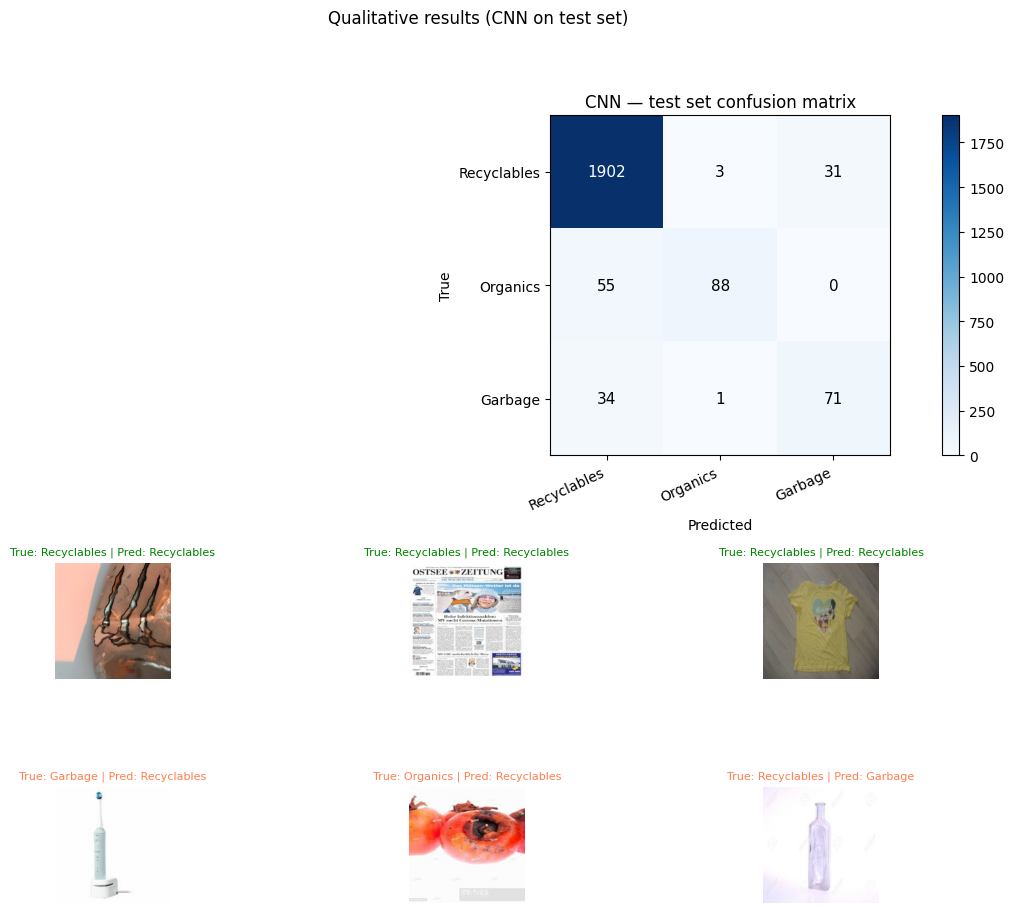

Saved: qualitative_results.png


In [12]:
# --- Qualitative figure: confusion matrix + sample thumbnails ---
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

try:
    from sklearn.metrics import confusion_matrix
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-learn', '-q'])
    from sklearn.metrics import confusion_matrix

cnn.eval()
test_ds = test_loader.dataset
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = cnn(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(pred)

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

rng = np.random.default_rng(42)
correct_idx = np.where(y_true == y_pred)[0]
wrong_idx = np.where(y_true != y_pred)[0]
n_c = min(3, len(correct_idx))
n_w = min(3, len(wrong_idx))
pick_c = rng.choice(correct_idx, size=n_c, replace=False) if n_c else np.array([], dtype=int)
pick_w = rng.choice(wrong_idx, size=n_w, replace=False) if n_w else np.array([], dtype=int)
examples = np.concatenate([pick_c, pick_w]).astype(int)

fig = plt.figure(figsize=(11, 9))
ax0 = plt.subplot2grid((4, 3), (0, 0), rowspan=2, colspan=3)
im = ax0.imshow(cm, interpolation='nearest', cmap='Blues')
ax0.set_xticks([0, 1, 2])
ax0.set_yticks([0, 1, 2])
ax0.set_xticklabels(TARGET_NAMES, rotation=25, ha='right')
ax0.set_yticklabels(TARGET_NAMES)
ax0.set_ylabel('True')
ax0.set_xlabel('Predicted')
th = cm.max() / 2.0 if cm.max() > 0 else 0.5
for i in range(3):
    for j in range(3):
        ax0.text(j, i, int(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > th else 'black', fontsize=11)
plt.colorbar(im, ax=ax0, fraction=0.046)
ax0.set_title('CNN — test set confusion matrix')

for k in range(min(6, len(examples))):
    ti = int(examples[k])
    ax = plt.subplot2grid((4, 3), (2 + k // 3, k % 3))
    real_idx = test_ds.indices[ti]
    path, _ = test_ds.samples[real_idx]
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.axis('off')
    tname = TARGET_NAMES[int(y_true[ti])]
    pname = TARGET_NAMES[int(y_pred[ti])]
    ok = y_true[ti] == y_pred[ti]
    ax.set_title(f'True: {tname} | Pred: {pname}', fontsize=8, color=('green' if ok else 'coral'))

plt.suptitle('Qualitative results (CNN on test set)', fontsize=12, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qualitative_results.png')

In [ ]:
# --- 类别分布（与 ds 一致；先运行「数据统计」cell）---
try:
    counts = {}
    for _, label in ds.samples:
        counts[label] = counts.get(label, 0) + 1
    print('=== Class counts (3-class) ===')
    for i, name in enumerate(TARGET_NAMES):
        print(f'  {name}: {counts.get(i, 0)}')
    print(f'  Total: {len(ds)}')
except NameError:
    print('Run the 数据统计 cell first. Using example counts.')
    counts = {0: 12888, 1: 985, 2: 697}

def latex_num(n):
    return f'{n:,}'.replace(',', '{,}')

print('\n=== LaTeX: class counts table (copy to final_report.tex) ===')
print(r'\begin{tabular}{@{}lc@{}}')
print(r'    \toprule')
print(r'    \textbf{Stream} & \textbf{Images} \\')
print(r'    \midrule')
for i, name in enumerate(TARGET_NAMES):
    print(f'    {name} & {latex_num(counts.get(i, 0))} \\\\')
tot = sum(counts.get(i, 0) for i in range(3))
print(r'    \midrule')
print(f'    \\textbf{{Total}} & {latex_num(tot)} \\\\')
print(r'    \bottomrule')
print(r'\end{tabular}')

# --- 结果汇总：优先用当前 session 的训练结果 ---
import pandas as pd
crit = nn.CrossEntropyLoss()
if 'history_baseline' in dir() and 'history_cnn' in dir():
    val_b = max(history_baseline['val_acc'])
    val_c = max(history_cnn['val_acc'])
else:
    val_b, val_c = 0.8934, 0.9524
if all(x in dir() for x in ['baseline', 'cnn', 'test_loader']):
    _, test_b = evaluate(baseline, test_loader, crit, device)
    _, test_c = evaluate(cnn, test_loader, crit, device)
else:
    test_b, test_c = 0.8915, 0.9515
bp = count_params(baseline) if 'baseline' in dir() else 38568707
cp = count_params(cnn) if 'cnn' in dir() else 1702659
df = pd.DataFrame({
    'Model': ['Baseline (MLP)', 'Primary (CNN)'],
    'Val acc (best)': [val_b, val_c],
    'Test acc': [test_b, test_c],
    'Parameters': [bp, cp],
})
display(df)
print('\n=== LaTeX: metrics rows ===')
print(f'Baseline (MLP) & $\\approx${val_b:.4f} & {test_b:.4f} & {latex_num(bp)} \\\\')
print(f'Primary (CNN)  & {val_c:.4f} & {test_c:.4f} & {latex_num(cp)} \\\\')